#  MongoDB + Python 실습 (Windows)


**Python(pymongo)**을 이용해 CRUD, CSV, 이미지, 시각화까지 실습하는 내용을 담고 있습니다.

---
##  목차
1. MongoDB 설치 및 환경 설정
2. Python 환경 설정
3. MongoDB 연결 테스트
4. CRUD 실습
5. CSV 데이터 저장
6. 이미지 저장과 복원
7. 데이터 시각화

---

## MongoDB 5.0.33 설치 (Windows)

1. [MongoDB Community Download Center](https://www.mongodb.com/try/download/community) 접속
2. Version → 5.0.33, Platform → Windows, Package → MSI
3. 설치 시 **Complete**, **Run MongoDB as a Service** 선택
4. “MongoDB Compass” 설치 (GUI 기반 MongoDB 관리 툴)
5. 설치 후 환경변수 추가: `C:\\Program Files\\MongoDB\\Server\\5.0\\bin`

테스트 명령어 (명령 프롬프트):
```bash
mongod --version
mongo --version

서버실행
mongod
```

## Python 환경 설정

-pymongo 설치
$> pip install pymongo


-쥬피터 노트북 안에서 설치
--> ! pip install pymongo

In [1]:
! pip list

Package                   Version
------------------------- ------------
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.15.0
bleach                    6.4.0
brotlicffi                1.2.0.0
certifi                   2026.7.22
cffi                      2.1.0
charset-normalizer        3.4.7
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.2
cycler                    0.12.1
debugpy                   1.8.21
decorator                 5.3.1
defusedxml                0.7.1
dnspython                 2.8.0
exceptiongroup            1.3.1
executing                 2.2.1
fastjsonschema            2.21.2
fonttools                 4.63.0
h11                       0.16.0
httpcore                  1.0.9
httpx                     0.28.1
idna         

In [2]:
from pymongo import MongoClient

In [6]:
# MongoDB 로컬 서버 연결
client = MongoClient("mongodb://localhost:27017/")     # mongodb 접속 포트 : 27017

# MongoDB 데이터베이스 생성
db = client["advanced_ai"]

# 컬렉션 생성 (>>RDBMS table)
collection = db["students"]

# 데이터 삽입
collection.insert_one({"name": "홍길동", "age":23, "major": "컴퓨터공학"})

InsertOneResult(ObjectId('6a7bbd84fb7ecaf79cccee0b'), acknowledged=True)

# 기본 CRUD 실습
 : CRUD는 Create, Read, Update, Delete의 약자

In [9]:
# DB 생성 및 연결

client = MongoClient("mongodb://localhost:27017/")
db = client["advanced_ai"]
collection = db["students"]

In [10]:
# Create
collection.insert_many([
    {"name": "김철수", "age":21, "major": "물리학"},
    {"name": "박민수", "age":29, "major": "영문학"},
    {"name": "이영애", "age":34, "major": "수리학"},
    {"name": "김지영", "age":31, "major": "전자공학"},
    {"name": "홍수이", "age":28, "major": "경제학"},
    {"name": "최치유", "age":21, "major": "경영학"},
    {"name": "전순이", "age":41, "major": "법학"}
])
    

InsertManyResult([ObjectId('6a7bbffcfb7ecaf79cccee15'), ObjectId('6a7bbffcfb7ecaf79cccee16'), ObjectId('6a7bbffcfb7ecaf79cccee17'), ObjectId('6a7bbffcfb7ecaf79cccee18'), ObjectId('6a7bbffcfb7ecaf79cccee19'), ObjectId('6a7bbffcfb7ecaf79cccee1a'), ObjectId('6a7bbffcfb7ecaf79cccee1b')], acknowledged=True)

In [11]:
# Update
collection.update_one({"name":"김철수"}, {"$set": {"age": 45}})

UpdateResult({'n': 1, 'nModified': 1, 'ok': 1.0, 'updatedExisting': True}, acknowledged=True)

In [12]:
# Delete
collection.delete_one({"name": "김철수"})
collection.delete_one({"name": "전순이"})

DeleteResult({'n': 1, 'ok': 1.0}, acknowledged=True)

In [15]:
# Read
for student in collection.find():
    print(student)

client.close()

{'_id': ObjectId('6a7bbd3efb7ecaf79cccee07'), 'name': '홍길동', 'age': 23, 'major': '컴퓨터공학'}
{'_id': ObjectId('6a7bbfa3fb7ecaf79cccee0e'), 'name': '박민수', 'age': 29, 'major': '영문학'}
{'_id': ObjectId('6a7bbfa3fb7ecaf79cccee0f'), 'name': '이영애', 'age': 34, 'major': '수리학'}
{'_id': ObjectId('6a7bbfa3fb7ecaf79cccee10'), 'name': '김지영', 'age': 31, 'major': '전자공학'}
{'_id': ObjectId('6a7bbfa3fb7ecaf79cccee11'), 'name': '홍수이', 'age': 28, 'major': '경제학'}
{'_id': ObjectId('6a7bbffcfb7ecaf79cccee1a'), 'name': '최치유', 'age': 21, 'major': '경영학'}


# csv 파일 >> MongoDB 저장

In [16]:
import pandas as pd

In [17]:
# csv 파일 읽어오기
df = pd.read_csv('Subjects.csv')
df

,class,name,kor,eng,math,science
0,1,aaa,67,87,90,98
1,1,bbb,45,45,56,98
2,1,ccc,95,59,96,88
3,1,ddd,65,94,89,98
4,1,eee,45,65,78,98
5,1,fff,78,76,98,89
6,2,ggg,87,67,65,56
7,2,hhh,89,98,78,78
8,2,iii,100,78,56,65
9,2,jjj,99,89,87,87


In [18]:
# DB 생성 및 연결
client = MongoClient("mongodb://localhost:27017/")
db = client["advanced_ai"]
collection = db["students_csv"]

In [19]:
# DataFrame을 딕셔너리 리스트로 변환 후 MongoDB에 저장
collection.insert_many(df.to_dict("records"))     # df라는 dataframe을 [{}, {}, {}, {}....] 형태의 리스트로 변환
print("csv 데이터가 mongodb에 저장되었습니다.")                       

csv 데이터가 mongodb에 저장되었습니다.


In [20]:
# read
for students_csv in collection.find():
    print(students_csv)

client.close()

{'_id': ObjectId('6a7bc9b8fb7ecaf79cccee1d'), 'class': 1, 'name': 'aaa', 'kor': 67, 'eng': 87, 'math': 90, 'science': 98}
{'_id': ObjectId('6a7bc9b8fb7ecaf79cccee1e'), 'class': 1, 'name': 'bbb', 'kor': 45, 'eng': 45, 'math': 56, 'science': 98}
{'_id': ObjectId('6a7bc9b8fb7ecaf79cccee1f'), 'class': 1, 'name': 'ccc', 'kor': 95, 'eng': 59, 'math': 96, 'science': 88}
{'_id': ObjectId('6a7bc9b8fb7ecaf79cccee20'), 'class': 1, 'name': 'ddd', 'kor': 65, 'eng': 94, 'math': 89, 'science': 98}
{'_id': ObjectId('6a7bc9b8fb7ecaf79cccee21'), 'class': 1, 'name': 'eee', 'kor': 45, 'eng': 65, 'math': 78, 'science': 98}
{'_id': ObjectId('6a7bc9b8fb7ecaf79cccee22'), 'class': 1, 'name': 'fff', 'kor': 78, 'eng': 76, 'math': 98, 'science': 89}
{'_id': ObjectId('6a7bc9b8fb7ecaf79cccee23'), 'class': 2, 'name': 'ggg', 'kor': 87, 'eng': 67, 'math': 65, 'science': 56}
{'_id': ObjectId('6a7bc9b8fb7ecaf79cccee24'), 'class': 2, 'name': 'hhh', 'kor': 89, 'eng': 98, 'math': 78, 'science': 78}
{'_id': ObjectId('6a7bc9

# 1) 이미지 >> MongoDB에 저장

* 이미지 저장 : 이미지 --> base64 --> 바이너리로 변환(encode) --> 저장
* 이미지 불러오기 : base64 --> 바이너리 --> 이미지 객체로 변환(decode) 하여 출력

In [21]:
import base64
from io import BytesIO

In [23]:
# 이미지 읽어오기
with open("cat.jpg", "rb") as img_file:
    encoded = base64.b64encode(img_file.read()).decode("utf-8")

# DB 생성 및 연결
client = MongoClient("mongodb://localhost:27017/")
db = client["advanced_ai"]
collection = db["images"]

# MongoDB에 저장
collection.insert_one({"filename": "cat.jpg", "data": encoded})

InsertOneResult(ObjectId('6a7bcdfbfb7ecaf79cccee2a'), acknowledged=True)

# 2) MongoDB image --> python 출력

In [24]:
from PIL import Image

MongoDB에서 이미지를 읽어왔습니다.


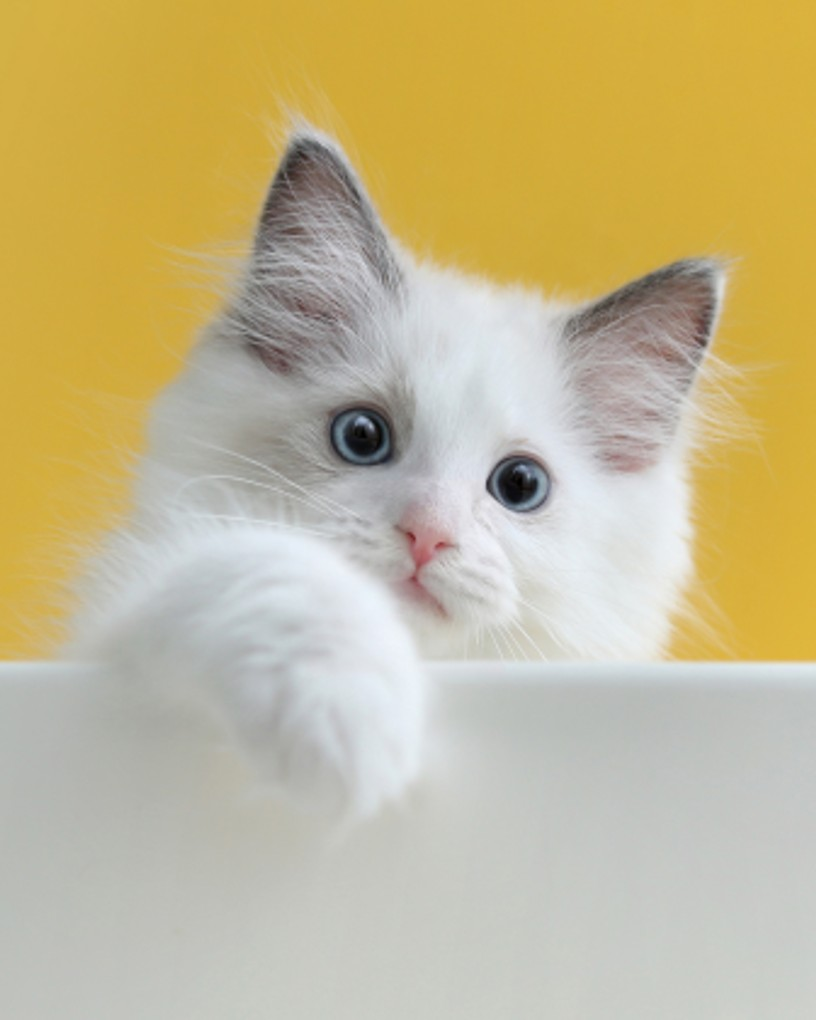

In [25]:
# mongodb에서 이미지 데이터 가져오기
document = collection.find_one({"filename":"cat.jpg"})
if document:
    img_data = document["data"]
    img_binary = base64.b64decode(img_data)          # base64 --> 바이너리로 변환
    img = Image.open(BytesIO(img_binary))            # 메모리에서 바로 이미지 객체 생성
    print("MongoDB에서 이미지를 읽어왔습니다.")
    display(img)                                     # 이미지 출력
else:
    print("cat.jpg 이미지를 찾을 수 없습니다.")

# 3) MongoDB student_csv 컬렉션에 있는 데이터를 읽어와 영어점수 막대 그래프를 출력하기

In [26]:
import pandas as pd                        # 데이터 처리 라이브러리
import seaborn as sns                      # 시각화 라이브러리
import matplotlib.pyplot as plt            # 시각화 라이브러리
from matplotlib import font_manager, rc    # 한글처리 매니너
from pymongo import MongoClient            # 몽고db 라이브러리

    class name  kor  eng  math  science
0       1  aaa   67   87    90       98
1       1  bbb   45   45    56       98
2       1  ccc   95   59    96       88
3       1  ddd   65   94    89       98
4       1  eee   45   65    78       98
5       1  fff   78   76    98       89
6       2  ggg   87   67    65       56
7       2  hhh   89   98    78       78
8       2  iii  100   78    56       65
9       2  jjj   99   89    87       87
10      2  kkk   98   45    56       54
11      2  lll   65   89    87       78


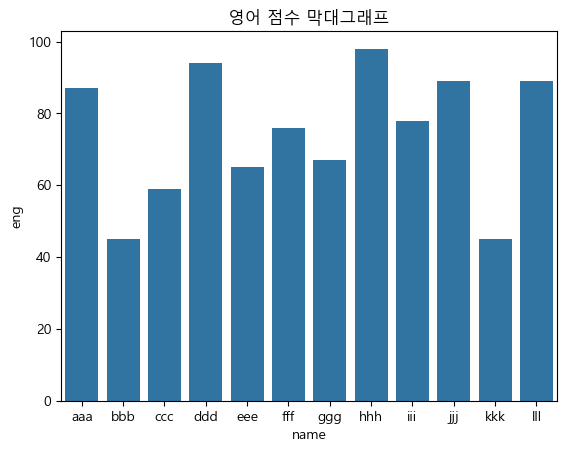

In [27]:
# 한글 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# 음수 값 표지 방지
plt.rcParams['axes.unicode_minus'] = False

# DB 생성 및 연결
client = MongoClient("mongodb://localhost:27017/")
db = client["advanced_ai"]
collection = db["students_csv"]

# MongoDB --> 파이썬 (DataFrame으로 변환)
data = pd.DataFrame(list(collection.find({}, {"_id":0})))
print(data)

# 시각화
sns.barplot(data=data, x="name", y="eng")
plt.title("영어 점수 막대그래프")
plt.show()

# db 종료
client.close()



## 1) 몽고 db 연결 > students 컬렉션의 데이터를 읽어오기
## 2) 파이썬으로 그래프 출력하기
  * 학생 나이 분포
  * 전공 별 학생 수
  * 전공 별 나이 분포

  name  age  major
0  홍길동   23  컴퓨터공학
1  박민수   29    영문학
2  이영애   34    수리학
3  김지영   31   전자공학
4  홍수이   28    경제학
5  최치유   21    경영학


C:\Users\admin\AppData\Local\Temp\ipykernel_11524\854133165.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="major", data=df, palette="pastel")
C:\Users\admin\AppData\Local\Temp\ipykernel_11524\854133165.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="major", y="age", data=df,  palette="Set2")


<function matplotlib.pyplot.show(close=None, block=None)>

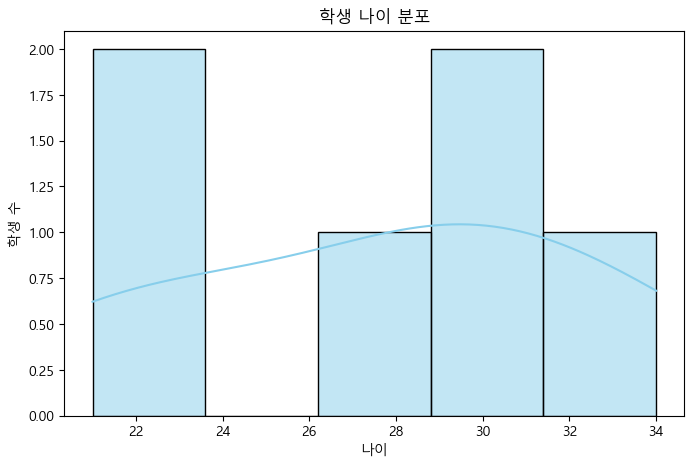

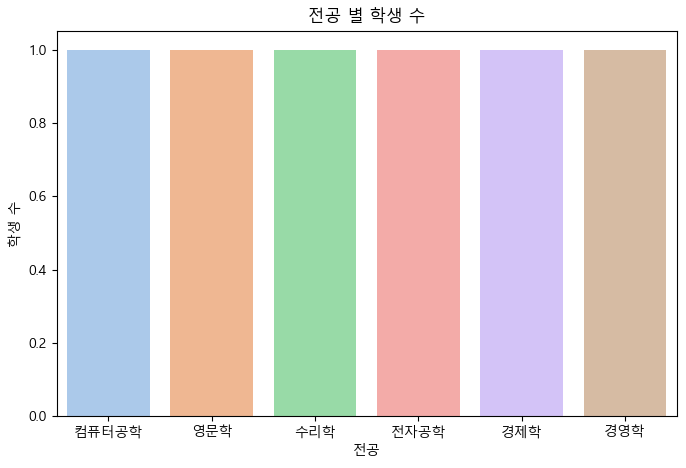

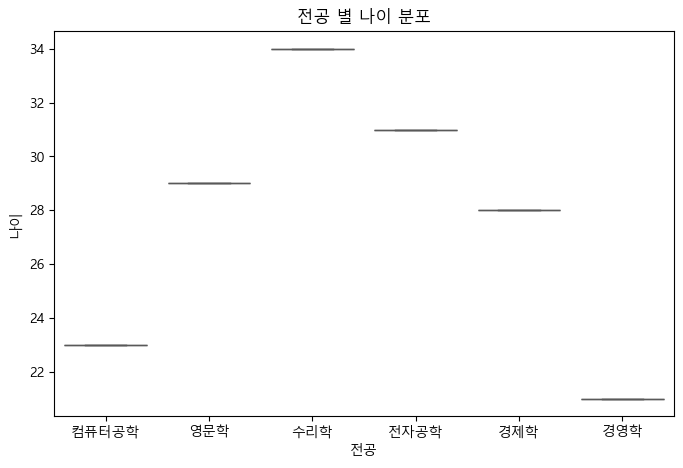

In [33]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rc

## 한글 폰트 설정 (Windows)

# Windows 기본 폰트: Malgun Gothic
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# 음수 값 표시 문제 방지
plt.rcParams['axes.unicode_minus'] = False

# -----------------------------
# MongoDB 연결 및 데이터 불러오기  (students 컬렉션)
# -----------------------------
client = MongoClient("mongodb://localhost:27017/")
db = client["advanced_ai"]
collection = db["students"]

cursor = collection.find({})
df = pd.DataFrame(list(cursor))
client.close()

# _id 컬럼 제거
if "_id" in df.columns:
    df = df.drop("_id", axis=1)

print(df)


# -----------------------------
#  나이 분포 히스토그램
# -----------------------------
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=5, kde=True, color="skyblue")
plt.title("학생 나이 분포")
plt.xlabel("나이")
plt.ylabel("학생 수")
plt.show

# -----------------------------
#  전공별 학생 수 막대그래프
# -----------------------------
plt.figure(figsize=(8,5))
sns.countplot(x="major", data=df, palette="pastel")
plt.title("전공 별 학생 수")
plt.xlabel("전공")
plt.ylabel("학생 수")
plt.show


# -----------------------------
#  전공별 나이 분포 박스플롯
# -----------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x="major", y="age", data=df,  palette="Set2")
plt.title("전공 별 나이 분포")
plt.xlabel("전공")
plt.ylabel("나이")
plt.show

